## Test Our Models!

### 1. Import Test dataset

In [1]:
import torch, torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

torch.manual_seed(42)

cuda:0


In [3]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.507, 0.487, 0.441), (0.267, 0.256, 0.276))
])

full_test_dataset = torchvision.datasets.CIFAR100(
    root='../CIFAR100', 
    train=False, 
    download=True, 
    transform=transform_test
)

Files already downloaded and verified


In [4]:
full_test_loader = DataLoader(
    full_test_dataset, 
    batch_size=64, 
    shuffle=False
)

In [5]:
head_classes = list(range(0, 33))
middle_classes = list(range(33, 67))
tail_classes = list(range(67, 100))

def create_subset_loader(dataset, target_classes, batch_size=64):
    indices = [i for i, (_, label) in enumerate(dataset) if label in target_classes]
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=2)
    return loader, len(indices)

In [6]:
head_test_loader, head_count = create_subset_loader(full_test_dataset, head_classes)
middle_test_loader, middle_count = create_subset_loader(full_test_dataset, middle_classes)
tail_test_loader, tail_count = create_subset_loader(full_test_dataset, tail_classes)

### Import Model

In [7]:
from models.model import *
from data.dataset import *
_, _, cls_num_list = get_dataloader(split=False)
base_balanced_model     = CifarResNet18().to(device);                          base_balanced_model.load_state_dict(torch.load("./models_path/Base_balanced.pth"))
base_unbalanced_model   = CifarResNet18().to(device);                          base_unbalanced_model.load_state_dict(torch.load("./models_path/Base_unbalanced.pth"))
ldam_balanced_model     = CifarResNet18(use_norm=True).to(device);             ldam_balanced_model.load_state_dict(torch.load("./models_path/LDAM_balanced.pth"))
ldam_unbalanced_model   = CifarResNet18(use_norm=True).to(device);             ldam_unbalanced_model.load_state_dict(torch.load("./models_path/LDAM_unbalanced.pth"))
multi_stage_model       = CifarResNet18_ThreeStage(cls_num_list=cls_num_list).to(device);   multi_stage_model.load_state_dict(torch.load("./models_path/stage3_CSE.pth"))


Files already downloaded and verified


d:\code\DeepLearningLab\project\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\code\DeepLearningLab\project\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\sttar\AppData\Local\Temp\ipykernel_22508\3525598853.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `we

<All keys matched successfully>

### Evaluate Model

In [8]:
from metrics.metric import acc_stage_model

print("=== Evaluate SupCon-Guided Hybrid Model ===")
acc_stage_model(multi_stage_model, full_test_loader, device)

=== Evaluate SupCon-Guided Hybrid Model ===
[LDAM classifier Accuracy]     64.4000%
[CSE classifier Accuracy]      62.4000%
[Confidence Strategy Accuracy] 64.3700%
[Softgate Strategy Accuracy]   64.4600


In [9]:
print("=== Measuring Head/Middle/Tail Accuracy for Multi-stage Model ===")
head_acc_ldam, head_acc_cse, head_acc_conf, head_acc_soft = acc_stage_model(multi_stage_model, head_test_loader, device, head_tail=True)
midd_acc_ldam, midd_acc_cse, midd_acc_conf, midd_acc_soft = acc_stage_model(multi_stage_model, middle_test_loader, device, head_tail=True)
tail_acc_ldam, tail_acc_cse, tail_acc_conf, tail_acc_soft = acc_stage_model(multi_stage_model, tail_test_loader, device, head_tail=True)

print(f"[LDAM strategy]       head acc: {head_acc_ldam:.4f}% | middle acc: {midd_acc_ldam:.4f}% | tail acc : {tail_acc_ldam:.4f}%")
print(f"[CSE strategy]        head acc: {head_acc_cse:.4f}% | middle acc: {midd_acc_cse:.4f}% | tail acc : {tail_acc_cse:.4f}%")
print(f"[Confidence strategy] head acc: {head_acc_conf:.4f}% | middle acc: {midd_acc_conf:.4f}% | tail acc : {tail_acc_conf:.4f}%")
print(f"[Softgate strategy]   head acc: {head_acc_soft:.4f}% | middle acc: {midd_acc_soft:.4f}% | tail acc : {tail_acc_soft:.4f}%")

=== Measuring Head/Middle/Tail Accuracy for Multi-stage Model ===
[LDAM strategy]       head acc: 72.5758% | middle acc: 65.7647% | tail acc : 54.8182%
[CSE strategy]        head acc: 70.4545% | middle acc: 64.3824% | tail acc : 52.3030%
[Confidence strategy] head acc: 72.5455% | middle acc: 65.6765% | tail acc : 54.8485%
[Softgate strategy]   head acc: 72.2121% | middle acc: 65.8235% | tail acc : 55.3030%


In [15]:
from metrics.metric import top_1_metric, relative_accuracy

print("=== Evaluate Single-Stage Models ===")
print("Balanced: trained at balanced dataset, Unbalanced: trained at unbalanced dataset")
base_balanced_acc = top_1_metric(base_balanced_model, full_test_loader, device, use_scl=False)
base_unbalanced_acc = top_1_metric(base_unbalanced_model, full_test_loader, device, use_scl=False)
ldam_balanced_acc = top_1_metric(ldam_balanced_model, full_test_loader, device, use_scl=False)
ldam_unbalanced_acc = top_1_metric(ldam_unbalanced_model, full_test_loader, device, use_scl=False)

print(f"[Base Model(CSE)] Balanced {base_balanced_acc:.4f}% | Unbalanced {base_unbalanced_acc:.4f}%")
print(f"[LDAM Model]      Balanced {ldam_balanced_acc:.4f}% | Unbalanced {ldam_unbalanced_acc:.4f}%")

=== Evaluate Single-Stage Models ===
Balanced: trained at balanced dataset, Unbalanced: trained at unbalanced dataset
[Base Model(CSE)] Balanced 72.0100% | Unbalanced 60.4900%
[LDAM Model]      Balanced 69.5900% | Unbalanced 61.1700%


In [16]:
print("=== Evaluate Head/Middle/Tail Accuracy at Single Stage Model(unbalanced) ===")

base_head_acc = top_1_metric(base_unbalanced_model, head_test_loader, device, use_scl=False)
base_mid_acc = top_1_metric(base_unbalanced_model, middle_test_loader, device, use_scl=False)
base_tail_acc = top_1_metric(base_unbalanced_model, tail_test_loader, device, use_scl=False)
ldam_head_acc = top_1_metric(ldam_unbalanced_model, head_test_loader, device, use_scl=False)
ldam_mid_acc = top_1_metric(ldam_unbalanced_model, middle_test_loader, device, use_scl=False)
ldam_tail_acc = top_1_metric(ldam_unbalanced_model, tail_test_loader, device, use_scl=False)

print(f"[Base Model(CSE)] Head {base_head_acc:.4f}% | Middle {base_mid_acc:.4f}% | Tail {base_tail_acc:.4f}%")
print(f"[LDAM Model]      Head {ldam_head_acc:.4f}% | Middle {ldam_mid_acc:.4f}% | Tail {ldam_tail_acc:.4f}%")

=== Evaluate Head/Middle/Tail Accuracy at Single Stage Model(unbalanced) ===
[Base Model(CSE)] Head 70.3636% | Middle 61.6176% | Tail 49.4545%
[LDAM Model]      Head 65.4848% | Middle 61.1176% | Tail 56.9091%


In [19]:
print("=== Calcuate Relative Accuracy of Models ===")
base_relative_acc = relative_accuracy(base_unbalanced_model, base_balanced_model, base_balanced_model, full_test_loader, device, use_scl=False)
ldam_relative_acc = relative_accuracy(ldam_unbalanced_model, base_balanced_model, ldam_balanced_model, full_test_loader, device, use_scl=False)
multi_relative_acc = relative_accuracy(multi_stage_model, base_balanced_model, base_balanced_model, full_test_loader, device, use_scl=False)

print(f"[Relative Accuracy] Base {base_relative_acc * 100:.4f}% | LDAM {ldam_relative_acc * 100:.4f}% | Multi {multi_relative_acc * 100:.4f}%")

=== Calcuate Relative Accuracy of Models ===
[Relative Accuracy] Base 84.0022% | LDAM 84.9465% | Multi 89.5153%


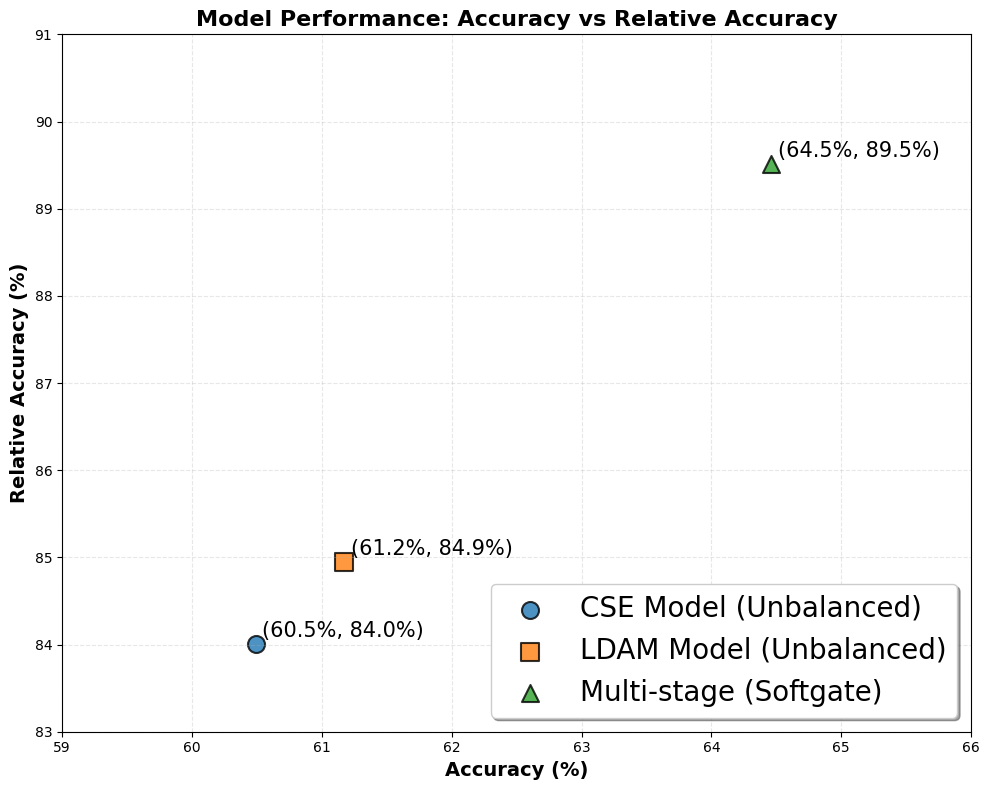

In [22]:
import matplotlib.pyplot as plt
import numpy as np


models = ['CSE Model (Unbalanced)', 'LDAM Model (Unbalanced)', 'Multi-stage (Softgate)']
accuracy = [60.49, 61.17, 64.46]  # x축: Accuracy
relative_accuracy = [84.0022, 84.9465, 89.5153]  # y축: Relative Accuracy

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 파란색, 주황색, 초록색
markers = ['o', 's', '^']  # 원, 사각형, 삼각형

# 플롯 생성
plt.figure(figsize=(10, 8))

for i, (model, acc, rel_acc) in enumerate(zip(models, accuracy, relative_accuracy)):
    plt.scatter(acc, rel_acc, 
               color=colors[i], 
               marker=markers[i], 
               s=150,  # 점 크기
               alpha=0.8,
               label=model,
               edgecolors='black',
               linewidth=1.5)

# 그래프 설정
plt.xlabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.ylabel('Relative Accuracy (%)', fontsize=14, fontweight='bold')
plt.title('Model Performance: Accuracy vs Relative Accuracy', fontsize=16, fontweight='bold')

# 격자 추가
plt.grid(True, alpha=0.3, linestyle='--')

# 범례 추가
plt.legend(fontsize=20, loc='lower right', frameon=True, fancybox=True, shadow=True)

# 축 범위 설정 (더 보기 좋게)
plt.xlim(59, 66)
plt.ylim(83, 91)

# 각 점에 값 표시
for i, (acc, rel_acc, model) in enumerate(zip(accuracy, relative_accuracy, models)):
    plt.annotate(f'({acc:.1f}%, {rel_acc:.1f}%)', 
                xy=(acc, rel_acc), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=15,
                ha='left')

# 레이아웃 조정
plt.tight_layout()

# 그래프 표시
plt.show()